In [4]:
# Importing required libraries

import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# NLP libraries
import nltk
import re

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Download stopwords
nltk.download('stopwords')

from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\renji\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
pip install nltk

  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   -------------------- ------------------- 0.8/1.6 MB 1.9 MB/s eta 0:00:01
   --------------------------------- ------ 1.3/1.6 MB 2.3 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 2.3 MB/s  0:00:01
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)

   ---------------------------------------- 0/3 [tqdm]
   ---------------------------------------- 0/3 [tqdm]
   ---------------------------------------- 0/3 [tqdm]
   ---------------------------------------- 0/3 [tqdm]
   ---------------------------------------- 0/3 [tqdm]
   ---------------------------------------- 0/3 [tqdm]
   ------------- -------------------------- 1/3 [regex]
 

In [5]:
import nltk

print("NLTK installed successfully")

NLTK installed successfully


In [6]:
# Importing required libraries

import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# NLP libraries
import nltk
import re

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Downloading stopwords
nltk.download('stopwords')

# Importing stopwords
from nltk.corpus import stopwords

print("All libraries imported successfully")

All libraries imported successfully


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\renji\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [9]:
# Loading the dataset

df = pd.read_csv("IMDB Dataset.csv")

# Displaying first 5 rows

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [10]:
# Displaying basic information about dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [11]:
# Checking number of rows and columns

print("Dataset Shape:", df.shape)

Dataset Shape: (50000, 2)


In [12]:
# Counting positive and negative reviews

print(df['sentiment'].value_counts())

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [13]:
# Creating stopwords set

stop_words = set(stopwords.words('english'))

# Displaying first few stopwords

print(list(stop_words)[:10])

['of', 'those', 'was', 'she', "wouldn't", 'my', 'we', 'over', 'if', 'some']


In [14]:
# Function for cleaning text data

def clean_text(text):
    
    # Convert text to lowercase
    text = text.lower()
    
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Split sentence into words
    words = text.split()
    
    # Remove stopwords
    words = [word for word in words if word not in stop_words]
    
    # Join words back into sentence
    text = " ".join(words)
    
    return text

In [16]:
# Testing cleaning function

sample_text = "This movie was AMAZING!!! 100% recommended."

cleaned = clean_text(sample_text)

print(cleaned)

movie amazing recommended


In [17]:
# Applying cleaning function to all reviews

df['cleaned_review'] = df['review'].apply(clean_text)

# Display first 5 rows

df.head()

,review,sentiment,cleaned_review
0,One of the other reviewers has mentioned that ...,positive,one reviewers mentioned watching oz episode yo...
1,A wonderful little production. <br /><br />The...,positive,wonderful little production br br filming tech...
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,basically theres family little boy jake thinks...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love time money visually stunni...


In [18]:
# Creating CountVectorizer object

vectorizer = CountVectorizer(max_features=5000)

# Converting cleaned text into numerical features

X = vectorizer.fit_transform(df['cleaned_review'])

# Target column

y = df['sentiment']

print("Feature extraction completed")

Feature extraction completed


In [19]:
# Checking feature matrix shape

print(X.shape)

(50000, 5000)


In [20]:
# Splitting data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Data splitting completed")

Data splitting completed


In [21]:
# Checking training and testing data shapes

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (40000, 5000)
X_test shape: (10000, 5000)
y_train shape: (40000,)
y_test shape: (10000,)


In [22]:
# Creating Logistic Regression model

model = LogisticRegression()

# Training the model using training data

model.fit(X_train, y_train)

print("Model training completed")

Model training completed


C:\Users\renji\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [23]:
# Creating Logistic Regression model with increased iterations

model = LogisticRegression(max_iter=1000)

# Training the model

model.fit(X_train, y_train)

print("Model training completed successfully")

Model training completed successfully


In [24]:
# Predicting sentiments for test data

y_pred = model.predict(X_test)

print("Prediction completed")

Prediction completed


In [25]:
# Displaying first 10 predictions

print(y_pred[:10])

['negative' 'positive' 'negative' 'positive' 'negative' 'positive'
 'positive' 'positive' 'negative' 'negative']


In [26]:
# Calculating model accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.8751


In [27]:
# Displaying classification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.88      0.87      0.87      4961
    positive       0.87      0.88      0.88      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [28]:
# Creating confusion matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[4308  653]
 [ 596 4443]]


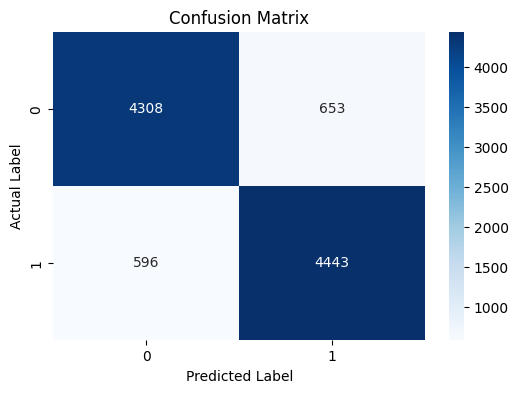

In [29]:
# Visualizing confusion matrix using heatmap

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

# Adding labels and title

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

# Displaying plot

plt.show()

In [30]:
# Testing model with custom review

sample_review = ["This movie was absolutely fantastic and amazing"]

# Cleaning the review

cleaned_review = [clean_text(text) for text in sample_review]

# Converting text into numerical features

review_vector = vectorizer.transform(cleaned_review)

# Predicting sentiment

prediction = model.predict(review_vector)

# Displaying result

print("Predicted Sentiment:", prediction[0])

Predicted Sentiment: positive


In [31]:
# Testing model with custom review

sample_review = ["This movie was absolutely fantastic and amazing"]

# Cleaning the review

cleaned_review = [clean_text(text) for text in sample_review]

# Converting text into numerical features

review_vector = vectorizer.transform(cleaned_review)

# Predicting sentiment

prediction = model.predict(review_vector)

# Displaying result

print("Predicted Sentiment:", prediction[0])

Predicted Sentiment: positive


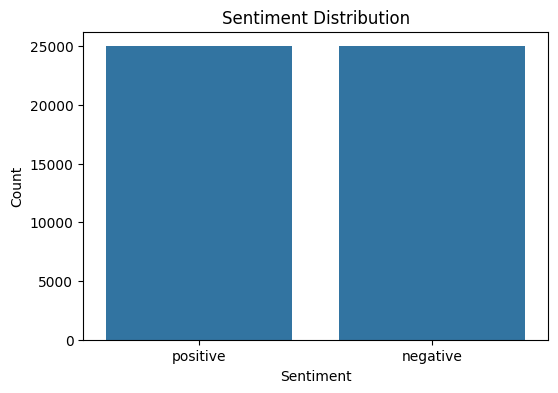

In [32]:
# Visualizing sentiment distribution

plt.figure(figsize=(6,4))

sns.countplot(
    x='sentiment',
    data=df
)

# Adding title and labels

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

# Displaying graph

plt.show()

In [33]:
# Creating review length column

df['review_length'] = df['review'].apply(len)

# Display first rows

df.head()

,review,sentiment,cleaned_review,review_length
0,One of the other reviewers has mentioned that ...,positive,one reviewers mentioned watching oz episode yo...,1761
1,A wonderful little production. <br /><br />The...,positive,wonderful little production br br filming tech...,998
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...,926
3,Basically there's a family where a little boy ...,negative,basically theres family little boy jake thinks...,748
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love time money visually stunni...,1317


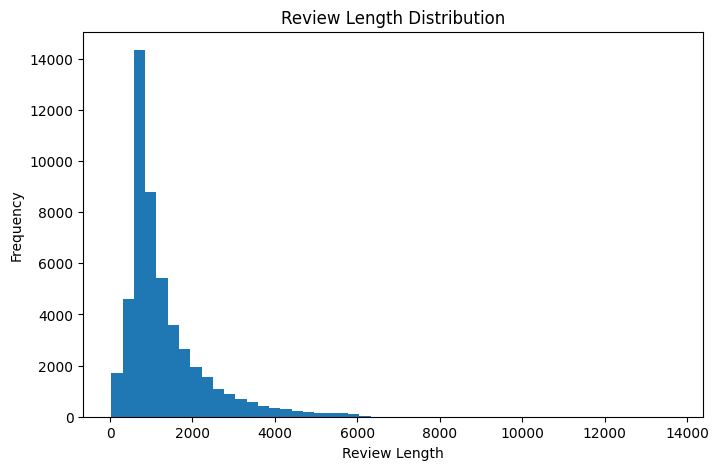

In [34]:
# Visualizing review length distribution

plt.figure(figsize=(8,5))

plt.hist(df['review_length'], bins=50)

# Adding labels and title

plt.title("Review Length Distribution")
plt.xlabel("Review Length")
plt.ylabel("Frequency")

# Display plot

plt.show()

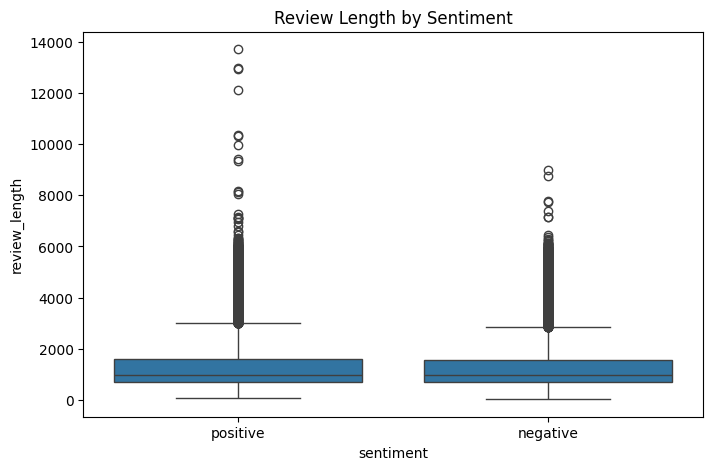

In [35]:
# Comparing review lengths by sentiment

plt.figure(figsize=(8,5))

sns.boxplot(
    x='sentiment',
    y='review_length',
    data=df
)

# Adding title

plt.title("Review Length by Sentiment")

# Display plot

plt.show()

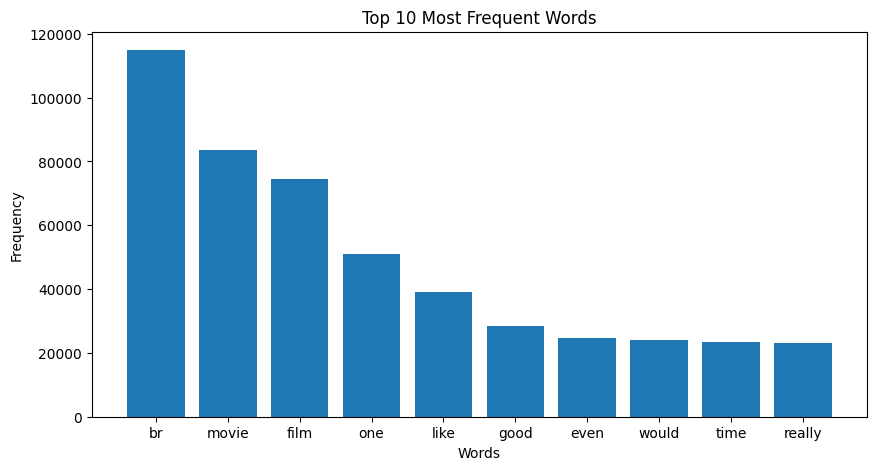

In [36]:
# Combining all cleaned reviews

all_words = " ".join(df['cleaned_review'])

# Splitting words

word_list = all_words.split()

# Counting word frequency

from collections import Counter

word_freq = Counter(word_list)

# Getting top 10 words

common_words = word_freq.most_common(10)

# Separating words and counts

words = [word[0] for word in common_words]
counts = [word[1] for word in common_words]

# Plotting

plt.figure(figsize=(10,5))

plt.bar(words, counts)

# Adding title and labels

plt.title("Top 10 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")

# Display plot

plt.show()

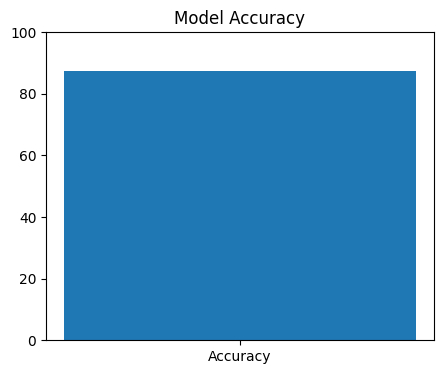

In [37]:
# Visualizing model accuracy

accuracy_percentage = accuracy * 100

plt.figure(figsize=(5,4))

plt.bar(
    ['Accuracy'],
    [accuracy_percentage]
)

# Adding title

plt.title("Model Accuracy")

# Adding y-axis limit

plt.ylim(0, 100)

# Display plot

plt.show()